In [9]:
# 라이브러리 기본 참조
from hossam import load_data
from pandas import DataFrame, melt
from matplotlib import pyplot as plt
from matplotlib import font_manager as fm
import seaborn as sb
import numpy as np
# 선형회귀를 위한 참조
import statsmodels.api as sm
from statsmodels.formula.api import ols
# 결과 검정을 위한 참조
from statsmodels.stats.diagnostic import linear_reset
from scipy.stats import zscore, probplot, shapiro, anderson
from statsmodels.stats.api import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
# VIF값을 계산하기 위한 참조
from statsmodels.stats.outliers_influence import variance_inflation_factor
import seaborn as sns


In [10]:
my_dpi = 200 # 이미지 선명도(100~300)
fpath = "./NotoSansKR-Regular.ttf" # 한글을 지원하는 폰트 파일의 경로
fm.fontManager.addfont(fpath) # 폰트의 글꼴을 시스템에 등록함
fprop = fm.FontProperties(fname=fpath) # 폰트의 속성을 읽어옴
fname = fprop.get_name() # 읽어온 속성에서 폰트 이름 추출
plt.rcParams['font.family'] = fname # 그래프에 한글 폰트 적용
plt.rcParams['font.size'] = 6 # 기본 폰트 크기
plt.rcParams['axes.unicode_minus'] = False # 그래프에 마이너스 깨짐 방지

In [11]:
origin = load_data('diamonds')
origin

[data] https://data.hossam.kr/data/lab12_/diamonds.xlsx
[desc] 다이아몬드를 커팅, 색상, 투명도, 가격 및 기타 속성 조사한 데이터 셋 (출처: https://www.kaggle.com/datasets/shivam2503/diamonds)

field    description
-------  -------------------------------------------------------------------------------------------------
price    price in US dollars ($326 ~ $18,823)
carat    weight of the diamond (0.2~5.01)
cut      quality of the cut (Fair, Good, Very Good, Premium, Ideal)
color    diamond colour, from J (worst) to D (best)
clarity  a measurement of how clear the diamond is (I1 (worst), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (best))
x        length in mm (0~10.74)
y        width in mm (0--58.9)
z        depth in mm (0--31.8)
depth    total depth percentage = z / mean(x, y) = 2 * z / (x + y) (43--79)
table    width of top of diamond relative to widest point (43--95)



,price,carat,cut,color,clarity,x,y,z,depth,table
0,326,0.23,Ideal,E,SI2,3.95,3.98,2.43,61.5,55.0
1,326,0.21,Premium,E,SI1,3.89,3.84,2.31,59.8,61.0
2,327,0.23,Good,E,VS1,4.05,4.07,2.31,56.9,65.0
3,334,0.29,Premium,I,VS2,4.20,4.23,2.63,62.4,58.0
4,335,0.31,Good,J,SI2,4.34,4.35,2.75,63.3,58.0
...,...,...,...,...,...,...,...,...,...,...
53935,2757,0.72,Ideal,D,SI1,5.75,5.76,3.50,60.8,57.0
53936,2757,0.72,Good,D,SI1,5.69,5.75,3.61,63.1,55.0
53937,2757,0.70,Very Good,D,SI1,5.66,5.68,3.56,62.8,60.0
53938,2757,0.86,Premium,H,SI2,6.15,6.12,3.74,61.0,58.0


x,y,z에 빈 값 있는지 확인<br>
이상치 확인

In [12]:
na_sum = origin[['x', 'y', 'z']].isna().sum()
len(na_sum)
print(f"빈값은 {na_sum}")
print(f"빈값 개수: {len(na_sum)}")


빈값은 x    0
y    0
z    0
dtype: int64
빈값 개수: 3


cut,color, clarity 품질 변수들이 몇 개의 범주들로 구성되어있을까?

In [13]:
print(f"""
cut 범주 수: {origin['cut'].nunique()}
color 범주 수: {origin['color'].nunique()}
clarity 범주 수: {origin['clarity'].nunique()}
""")



cut 범주 수: 5
color 범주 수: 7
clarity 범주 수: 8



빈도

In [14]:
origin['cut'].value_counts()
origin['color'].value_counts()
origin['clarity'].value_counts()


clarity
SI1     13065
VS2     12258
SI2      9194
VS1      8171
VVS2     5066
VVS1     3655
IF       1790
I1        741
Name: count, dtype: int64

📝 미션 2. “가격 데이터는 어떤 모습일까?”

가격이 고르게 분포되어있을가?<br>
특정구간에 몰려있을까?

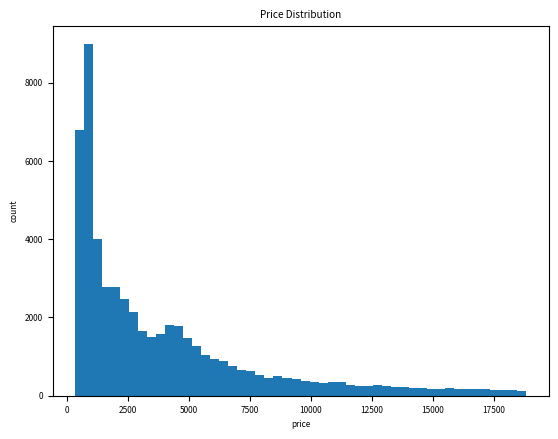

저가구간에 데이터가 집중, 고가 영역으로 갈수록 관측치가 급격히 줄어들어 오른쪽 꼬리가 긴 분포를 보인다.
 그리고, carat역시 작은 값에 집중되어 있어 특정 단위에서 관측치가 몰리는 계단형 분포를 보임.


In [15]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(origin['price'], bins=50)
plt.title('Price Distribution')
plt.xlabel('price')
plt.ylabel('count')
plt.show()
print(f"저가구간에 데이터가 집중, 고가 영역으로 갈수록 관측치가 급격히 줄어들어 오른쪽 꼬리가 긴 분포를 보인다.\n 그리고, carat역시 작은 값에 집중되어 있어 특정 단위에서 관측치가 몰리는 계단형 분포를 보임.")

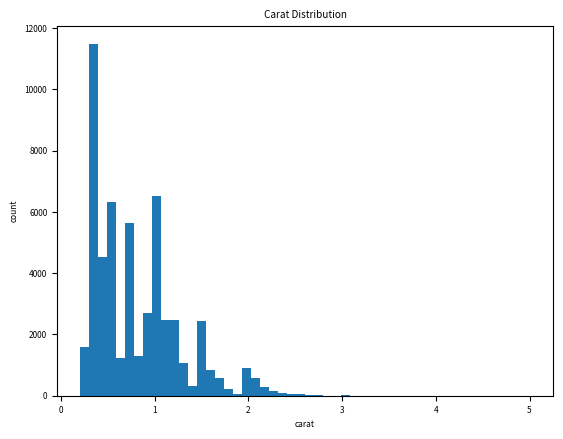

특정값에서 쏠림 현상이 발생했습니다.
즉, 스파이크 현상이 발생했다고 볼 수 있습니다.
또한, 작은 캐럿의 다이아몬드가 압도적으로 많은 것으로 확인되어 오른쪽으로 꼬리가 길다고 판단할 수 있습니다.
비대칭적 급락을 발견했습니다.
0.99캐럿에서 빈도수가 급격히 줄어드는 것을 알 수있습니다.
특정구간에서 빈도수가 집중되는 다봉형 패턴을 통해
 사람들의 선호도가 높은 특정 중량(0.5,1.0캐럿)에서 집중되었다는 것을 알 수 있습니다.
이를 통해, 시장 가격이 특정 중량을 기준으로 급등하기 때문에, 연마과정에서 의도적으로 해당 무게를 맞추려고 한 경향이 반영된 것으로 해석됩니다.


In [16]:
plt.figure()
plt.hist(origin['carat'], bins=50)
plt.title('Carat Distribution')
plt.xlabel('carat')
plt.ylabel('count')
plt.show()
print(f"특정값에서 쏠림 현상이 발생했습니다.\n즉, 스파이크 현상이 발생했다고 볼 수 있습니다.\n또한, 작은 캐럿의 다이아몬드가 압도적으로 많은 것으로 확인되어 오른쪽으로 꼬리가 길다고 판단할 수 있습니다.")
print(f"비대칭적 급락을 발견했습니다.\n0.99캐럿에서 빈도수가 급격히 줄어드는 것을 알 수있습니다.")
print(f"특정구간에서 빈도수가 집중되는 다봉형 패턴을 통해\n 사람들의 선호도가 높은 특정 중량(0.5,1.0캐럿)에서 집중되었다는 것을 알 수 있습니다.\n이를 통해, 시장 가격이 특정 중량을 기준으로 급등하기 때문에, 연마과정에서 의도적으로 해당 무게를 맞추려고 한 경향이 반영된 것으로 해석됩니다.")

로그 변환은 왜 등장할까?

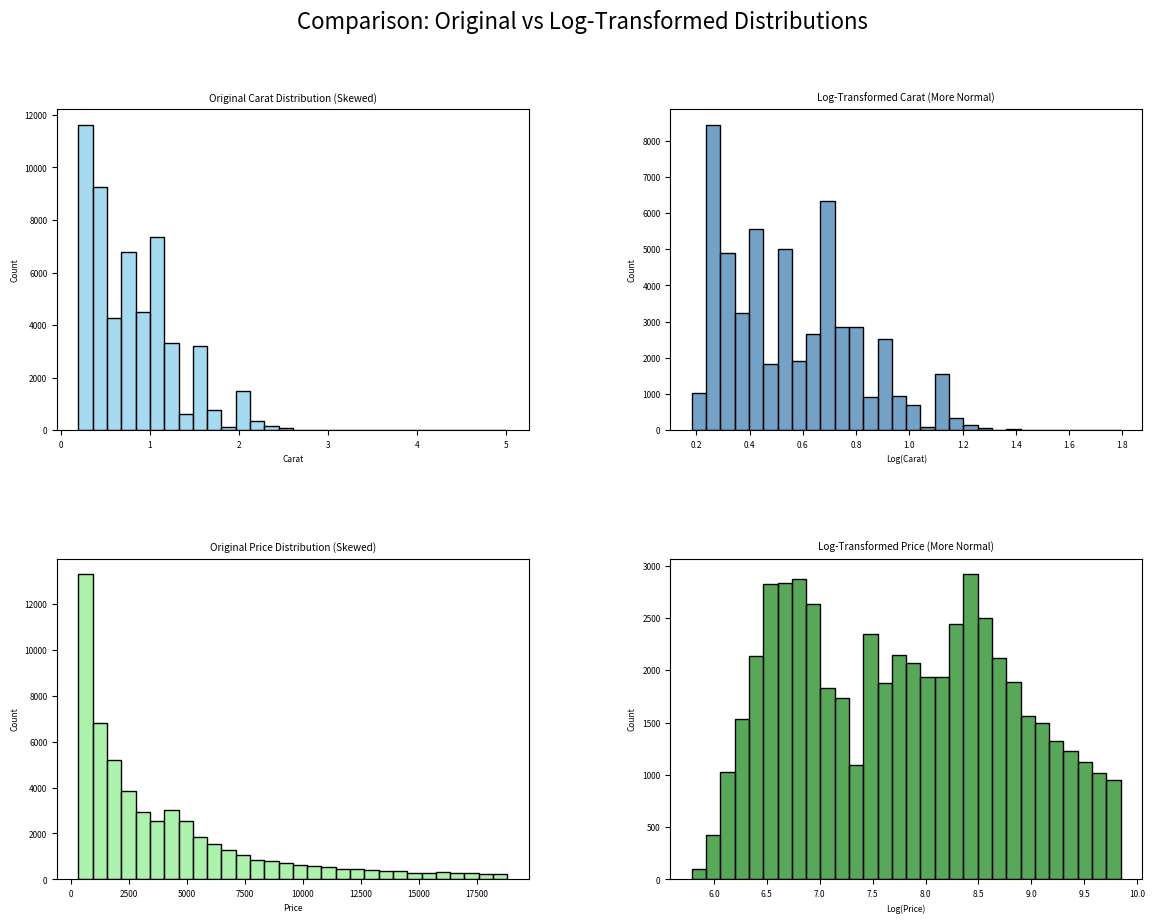

오른쪽으로 꼬리가 긴 것을 보아 carat중량이 작을수록 값이 크다는 것을 알게 됨.


In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. 데이터 로드 (seaborn 내장 데이터셋 활용)
# 만약 로컬 파일이 있다면: df = pd.read_csv('diamonds.csv')
try:
    df = sns.load_dataset('diamonds')
except:
    # 데이터셋 로드 실패 시 예시 데이터 생성 (실제 실행 시에는 이 부분은 무시됩니다)
    np.random.seed(42)
    n = 5000
    carat = np.random.exponential(scale=0.7, size=n) + 0.2
    price = 3000 * carat ** 2 + np.random.normal(0, 500, n)
    price = np.abs(price) + 100
    df = pd.DataFrame({'carat': carat, 'price': price})

# 2. 그래프 설정 (2행 2열)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plt.subplots_adjust(hspace=0.4, wspace=0.3) # 그래프 간 간격 조정

# --- Carat 분포 비교 ---
# (1) 원본 Carat
sns.histplot(df['carat'], kde=False, bins=30, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Original Carat Distribution (Skewed)')
axes[0, 0].set_xlabel('Carat')

# (2) 로그 변환 Carat
# np.log1p는 log(1 + x)를 계산하여 0일 때 -inf가 나오는 것을 방지합니다.
sns.histplot(np.log1p(df['carat']), kde=False, bins=30, ax=axes[0, 1], color='steelblue')
axes[0, 1].set_title('Log-Transformed Carat (More Normal)')
axes[0, 1].set_xlabel('Log(Carat)')

# --- Price 분포 비교 ---
# (3) 원본 Price
sns.histplot(df['price'], kde=False, bins=30, ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Original Price Distribution (Skewed)')
axes[1, 0].set_xlabel('Price')

# (4) 로그 변환 Price
sns.histplot(np.log1p(df['price']), kde=False, bins=30, ax=axes[1, 1], color='forestgreen')
axes[1, 1].set_title('Log-Transformed Price (More Normal)')
axes[1, 1].set_xlabel('Log(Price)')

# 전체 제목
plt.suptitle('Comparison: Original vs Log-Transformed Distributions', fontsize=16)

# 그래프 표시
plt.show()
print(f"오른쪽으로 꼬리가 긴 것을 보아 carat중량이 작을수록 값이 크다는 것을 알게 됨.")

품질 등급은 가격을 얼마나 설명해줄까?

C:\Users\itwill\AppData\Local\Temp\ipykernel_1488\195751731.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cut', y='price', data=df, order=cut_order, ax=axes[0], palette='viridis')
C:\Users\itwill\AppData\Local\Temp\ipykernel_1488\195751731.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='color', y='price', data=df, order=color_order, ax=axes[1], palette='viridis')
C:\Users\itwill\AppData\Local\Temp\ipykernel_1488\195751731.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='clarity', y='price', data=df, order=clarity_ord

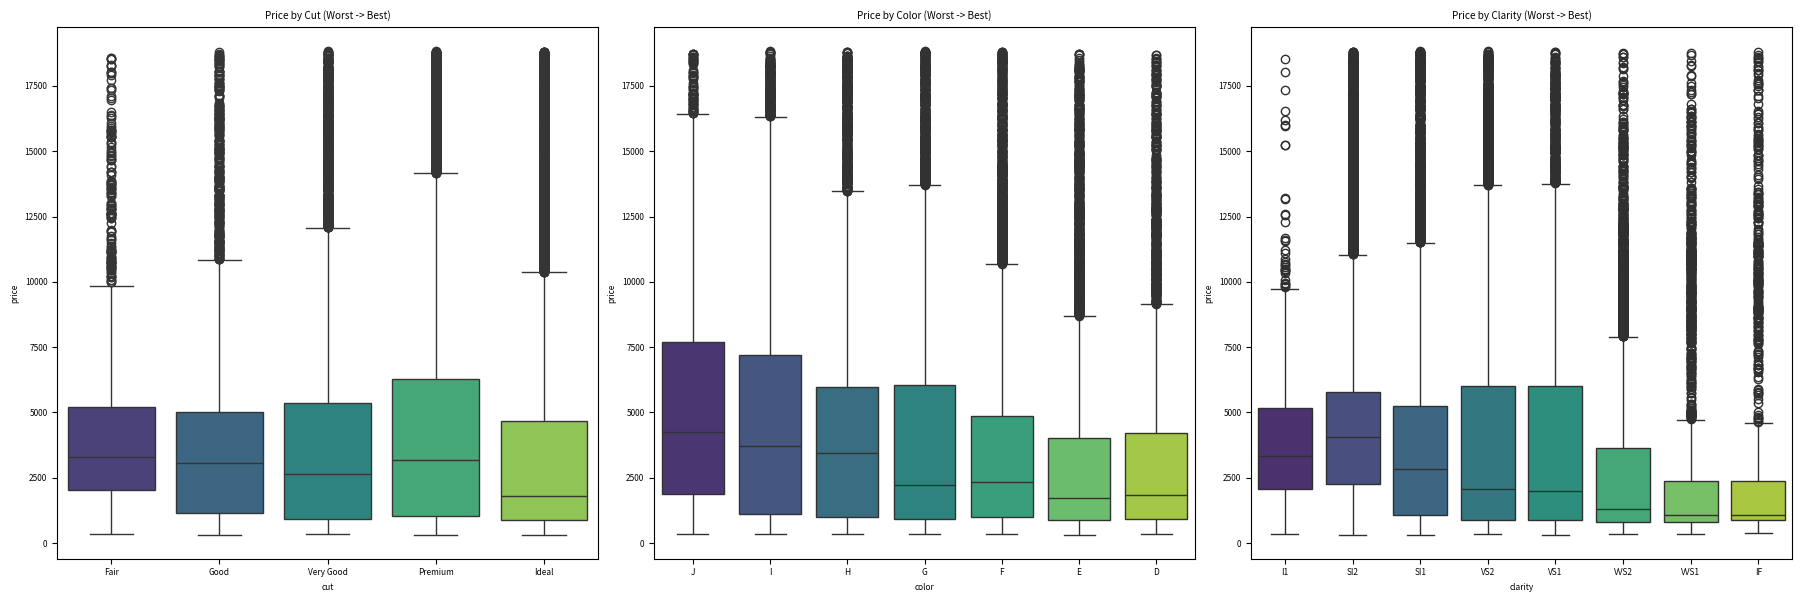

극과 극 차이가 엄청나다, 어떤 다이아몬드는 아주 싸고 어떤 것은 아주 비싸다
발견:Fair등급에는 작고 못난돌과 못 깎았지만 엄청 큰 돌이 뒤섞여 있음.
분포가 위 아래로 쫙 찢어지게 나타났음.즉, 가격이 특정 구간에 몰려있지 않고 가장 저가부터 초고가까지 매우 넓게 분포하고 있다.
성격이 균일하지 않고 잡탕이다.
또한, 예측하기 어렵다


In [18]:
# 1. Cut (컷): 못 깎은 것 -> 잘 깎은 것
# Fair가 제일 안 좋고, Ideal이 제일 좋습니다.
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']

# 2. Color (색상): 노란색(J) -> 투명색(D)
# J가 가장 노란끼가 돌고(나쁨), D가 가장 투명하고 비쌉니다(좋음).
# 알파벳 역순이라 헷갈리기 쉽습니다.
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D']

# 3. Clarity (투명도/내포물): 내포물 많음(I1) -> 완전 무결(IF)
# I1은 눈에 보일 정도, IF는 현미경으로도 안 보이는 수준입니다.
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']
import seaborn as sns
import matplotlib.pyplot as plt

# 데이터 로드
df = sns.load_dataset('diamonds')

# 그래프 그리기 준비
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# [핵심] order 파라미터에 위에서 만든 리스트를 넣어줍니다.
sns.boxplot(x='cut', y='price', data=df, order=cut_order, ax=axes[0], palette='viridis')
axes[0].set_title('Price by Cut (Worst -> Best)')

sns.boxplot(x='color', y='price', data=df, order=color_order, ax=axes[1], palette='viridis')
axes[1].set_title('Price by Color (Worst -> Best)')

sns.boxplot(x='clarity', y='price', data=df, order=clarity_order, ax=axes[2], palette='viridis')
axes[2].set_title('Price by Clarity (Worst -> Best)')

plt.tight_layout()
plt.show()

print(f"극과 극 차이가 엄청나다, 어떤 다이아몬드는 아주 싸고 어떤 것은 아주 비싸다")
print(f"발견:Fair등급에는 작고 못난돌과 못 깎았지만 엄청 큰 돌이 뒤섞여 있음.\n분포가 위 아래로 쫙 찢어지게 나타났음.즉, 가격이 특정 구간에 몰려있지 않고 가장 저가부터 초고가까지 매우 넓게 분포하고 있다.\n성격이 균일하지 않고 잡탕이다.\n또한, 예측하기 어렵다")

Y값이 carat인 박스플롯

C:\Users\itwill\AppData\Local\Temp\ipykernel_1488\2601883969.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cut', y='carat', data=df, order=cut_order, ax=axes[0], palette='viridis')
C:\Users\itwill\AppData\Local\Temp\ipykernel_1488\2601883969.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='color', y='carat', data=df, order=color_order, ax=axes[1], palette='viridis')
C:\Users\itwill\AppData\Local\Temp\ipykernel_1488\2601883969.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='clarity', y='carat', data=df, order=clarity_

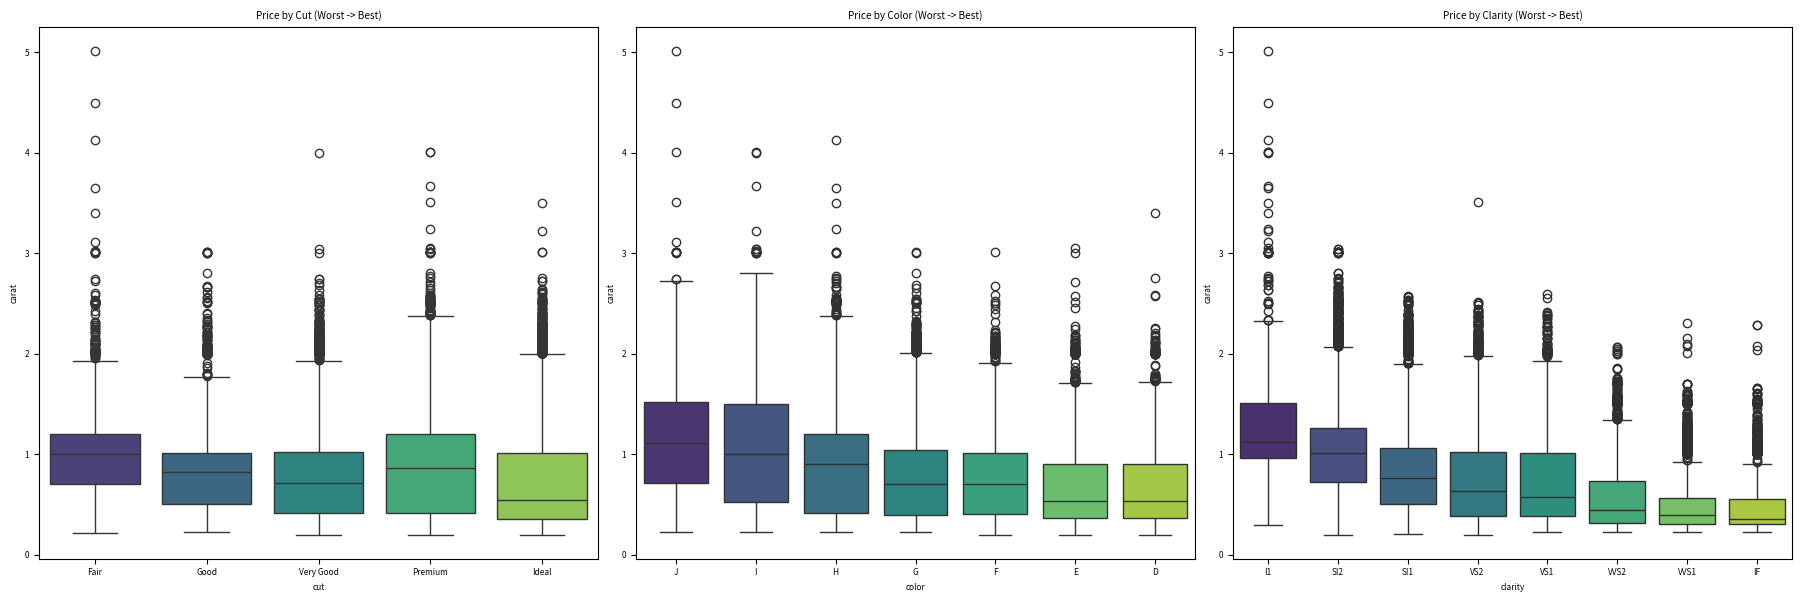

In [19]:
# 1. Cut (컷): 못 깎은 것 -> 잘 깎은 것
# Fair가 제일 안 좋고, Ideal이 제일 좋습니다.
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']

# 2. Color (색상): 노란색(J) -> 투명색(D)
# J가 가장 노란끼가 돌고(나쁨), D가 가장 투명하고 비쌉니다(좋음).
# 알파벳 역순이라 헷갈리기 쉽습니다.
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D']

# 3. Clarity (투명도/내포물): 내포물 많음(I1) -> 완전 무결(IF)
# I1은 눈에 보일 정도, IF는 현미경으로도 안 보이는 수준입니다.
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']
import seaborn as sns
import matplotlib.pyplot as plt

# 데이터 로드
df = sns.load_dataset('diamonds')

# 그래프 그리기 준비
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# [핵심] order 파라미터에 위에서 만든 리스트를 넣어줍니다.
sns.boxplot(x='cut', y='carat', data=df, order=cut_order, ax=axes[0], palette='viridis')
axes[0].set_title('Price by Cut (Worst -> Best)')

sns.boxplot(x='color', y='carat', data=df, order=color_order, ax=axes[1], palette='viridis')
axes[1].set_title('Price by Color (Worst -> Best)')

sns.boxplot(x='clarity', y='carat', data=df, order=clarity_order, ax=axes[2], palette='viridis')
axes[2].set_title('Price by Clarity (Worst -> Best)')

plt.tight_layout()
plt.show()

미션3.“로그 변환은 왜 등장할까?"

In [20]:
df = sns.load_dataset('diamonds')

# 로그 변환 변수 생성
df['log_price'] = np.log(df['price'])
df['log_carat'] = np.log(df['carat'])

히스토그램

(1) price 분포 비교

로그 변환 전, 저값 구간에 데이터가 과밀되어있으며 꼬리가 왼쪽으로 늘어져 있음.
로그 변환 후, 고값 소수 데이터가 분산,평균을 지배한다
또한, 봉우리가 여러 개 보임. 심리적 지향선이나 특정 구간이 존재다는 것을 알 수 있게 됨
     데이터가 중심에 모이게 되어 회귀분석의 성능이 좋아짐
즉 오차가 큰 로그 변환전 그래프에 비해 데이터가 중심에 모여있어, 회귀분석하기 편해 로그변환을 합니다.


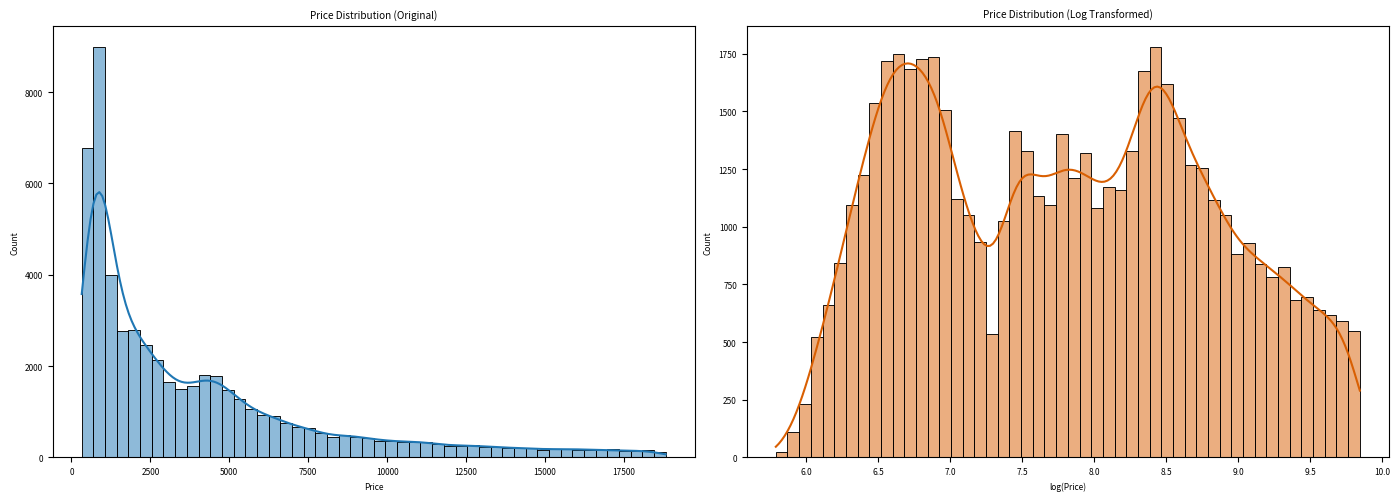

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 원본 price
sns.histplot(df['price'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Price Distribution (Original)')
axes[0].set_xlabel('Price')

# 로그 변환 price

sns.histplot(df['log_price'], bins=50, kde=True, ax=axes[1], color=sns.color_palette("Dark2")[1])
axes[1].set_title('Price Distribution (Log Transformed)')
axes[1].set_xlabel('log(Price)')
print(f"로그 변환 전, 저값 구간에 데이터가 과밀되어있으며 꼬리가 왼쪽으로 늘어져 있음.\n로그 변환 후, 고값 소수 데이터가 분산,평균을 지배한다")
print(f"또한, 봉우리가 여러 개 보임. 심리적 지향선이나 특정 구간이 존재다는 것을 알 수 있게 됨")
print(f"     데이터가 중심에 모이게 되어 회귀분석의 성능이 좋아짐\n즉 오차가 큰 로그 변환전 그래프에 비해 데이터가 중심에 모여있어, 회귀분석하기 편해 로그변환을 합니다.")
plt.tight_layout()
plt.show()


(2) carat 분포 비교

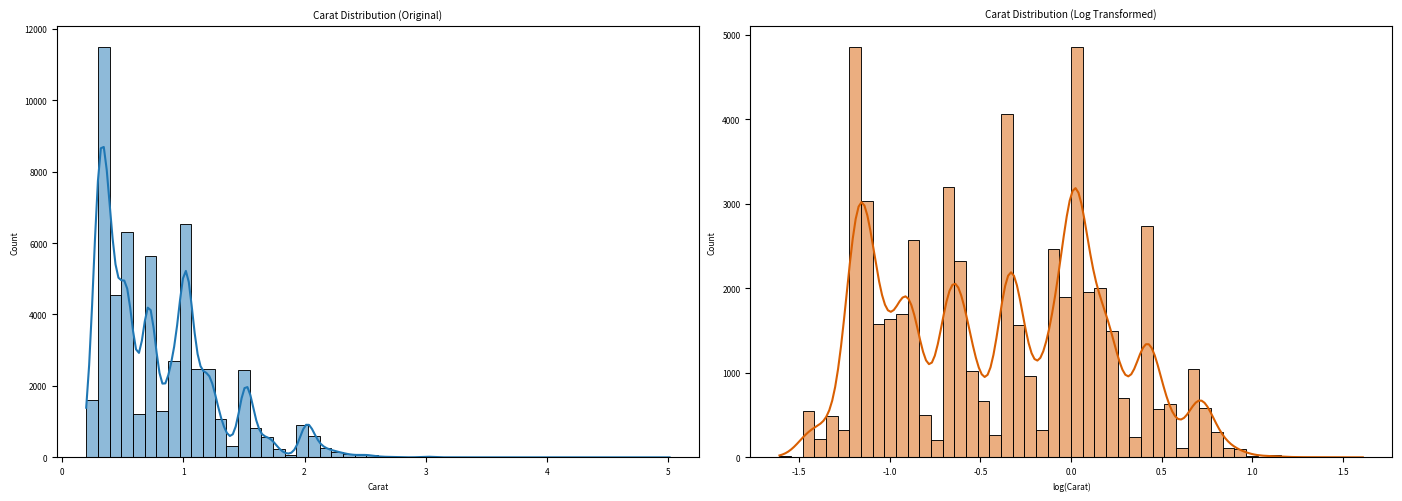

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 원본 carat
sns.histplot(df['carat'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Carat Distribution (Original)')
axes[0].set_xlabel('Carat')

# 로그 변환 carat
sns.histplot(df['log_carat'], bins=50, kde=True, ax=axes[1],color=sns.color_palette("Dark2")[1])
axes[1].set_title('Carat Distribution (Log Transformed)')
axes[1].set_xlabel('log(Carat)')

plt.tight_layout()
plt.show()


미션4<br>
cut, color, clarity에 따라 다이아몬드 가격 분포가 어떻게 달라지는지 시각화해 보자.<br>
중앙값, 분산, 분포의 겹침 정도를 관찰하며 다음 질문에 답해 보자.<br>
어떤 품질 변수는 가격 차이가 뚜렷한가?<br>
어떤 경우에는 등급이 달라도 가격이 크게 겹치는가?<br>
숫자보다 패턴과 느낌을 중심으로 정리해 보자.

cut,carat->price 사분위수

In [23]:
df.groupby('cut').agg(
    price_Q1=('price', lambda x: x.quantile(0.25)),
    price_Median=('price', 'median'),
    price_Q3=('price', lambda x: x.quantile(0.75)),
    carat_Q1=('carat', lambda x: x.quantile(0.25)),
    carat_Median=('carat', 'median'),
    carat_Q3=('carat', lambda x: x.quantile(0.75)),
)


C:\Users\itwill\AppData\Local\Temp\ipykernel_1488\3108617715.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('cut').agg(


,price_Q1,price_Median,price_Q3,carat_Q1,carat_Median,carat_Q3
cut,,,,,,
Ideal,878.00,1810.0,4678.50,0.35,0.54,1.01
Premium,1046.00,3185.0,6296.00,0.41,0.86,1.20
Very Good,912.00,2648.0,5372.75,0.41,0.71,1.02
Good,1145.00,3050.5,5028.00,0.50,0.82,1.01
Fair,2050.25,3282.0,5205.50,0.70,1.00,1.20


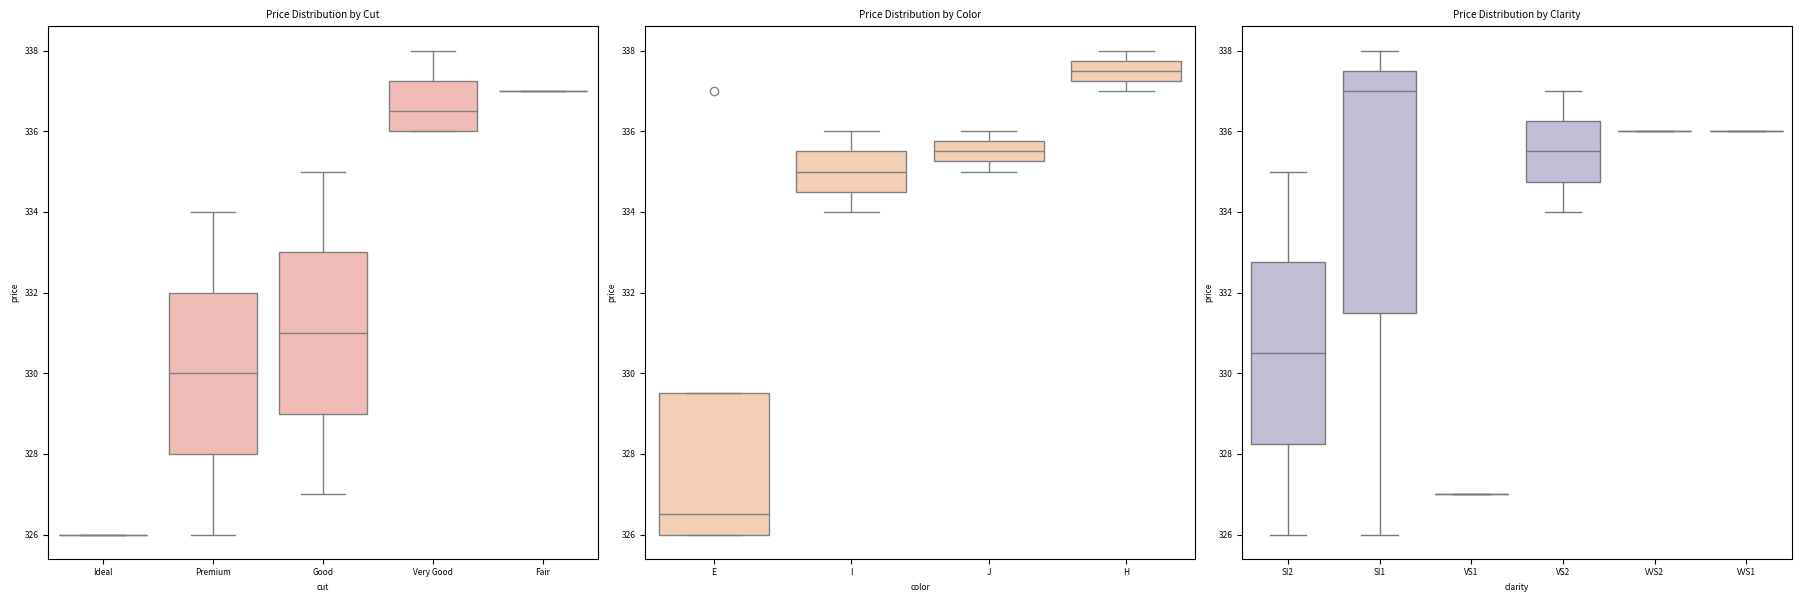

cut:Fair등급의 Q1값이 가장 높음.하지만,Q3값은 Premium보다 조금 적음. 즉, 모든 가격이 높진 않지만 무게가 무거워 Q1값,중앙값이 높다고 판단.
반면에 ideal다이아몬드가 최상급인데 가격이 가장 낮고 4분위수 범위가 가장 작음.
이를 통해 무게가 가장 적게 나가는 것을 알 수 있음.
color:


In [24]:
# 샘플 데이터 생성
data = {
    'price': [326, 326, 327, 334, 335, 336, 336, 337, 337, 338],
    'cut': ['Ideal', 'Premium', 'Good', 'Premium', 'Good', 'Very Good', 'Very Good', 'Very Good', 'Fair', 'Very Good'],
    'color': ['E', 'E', 'E', 'I', 'J', 'J', 'I', 'H', 'E', 'H'],
    'clarity': ['SI2', 'SI1', 'VS1', 'VS2', 'SI2', 'VVS2', 'VVS1', 'SI1', 'VS2', 'SI1']
}

df = pd.DataFrame(data)

# matplotlib Figure 설정
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Price vs Cut 박스 플롯
sns.boxplot(x='cut', y='price', data=df, ax=axes[0],color=sns.color_palette('Pastel1')[0])
axes[0].set_title('Price Distribution by Cut')

# Price vs Color 박스 플롯
sns.boxplot(x='color', y='price', data=df, ax=axes[1],color=sns.color_palette('Pastel2')[1])
axes[1].set_title('Price Distribution by Color')

# Price vs Clarity 박스 플롯
sns.boxplot(x='clarity', y='price', data=df, ax=axes[2],color=sns.color_palette('Set3')[2])
axes[2].set_title('Price Distribution by Clarity')

# 레이아웃 조정
plt.tight_layout()

# 플롯 출력
plt.show()
print(f"cut:Fair등급의 Q1값이 가장 높음.하지만,Q3값은 Premium보다 조금 적음. 즉, 모든 가격이 높진 않지만 무게가 무거워 Q1값,중앙값이 높다고 판단.\n반면에 ideal다이아몬드가 최상급인데 가격이 가장 낮고 4분위수 범위가 가장 작음.\n이를 통해 무게가 가장 적게 나가는 것을 알 수 있음.")
print(f"color:")

그렇다면 무게가 무거울수록 가격이 높을까?

🍭특정구간에 따른 가격이 분포되어있는지 알아봤다.<br>
cut별로 분류해서 가격의 차이가 있는지 알아봤다.

color와 price끼리 매칭

In [25]:
# 필요한 컬럼만 선택
df = origin[['cut','price']].copy()

# 서열 매핑
clarity_order = {
    'ideal': 1, 'premium': 2, 'Verygood': 3,
    'Good': 4
}



df['cut'].map(clarity_order)


df.head()


,cut,price
0,Ideal,326
1,Premium,326
2,Good,327
3,Premium,334
4,Good,335


In [26]:
# 필요한 컬럼만 선택
df = origin[['cut','price','carat']].copy()

# 서열 매핑
clarity_order = {
    'ideal': 1, 'premium': 2, 'Verygood': 3,
    'Good': 4
}



df['cut'].map(clarity_order)


df.head()





,cut,price,carat
0,Ideal,326,0.23
1,Premium,326,0.21
2,Good,327,0.23
3,Premium,334,0.29
4,Good,335,0.31


C:\Users\itwill\AppData\Local\Temp\ipykernel_1488\4227988291.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cut', y='price', data=df, order=cut_order, ax=axes[0], palette='viridis')
C:\Users\itwill\AppData\Local\Temp\ipykernel_1488\4227988291.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='color', y='price', data=df, order=color_order, ax=axes[1], palette='viridis')
C:\Users\itwill\AppData\Local\Temp\ipykernel_1488\4227988291.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='clarity', y='price', data=df, order=clarity_

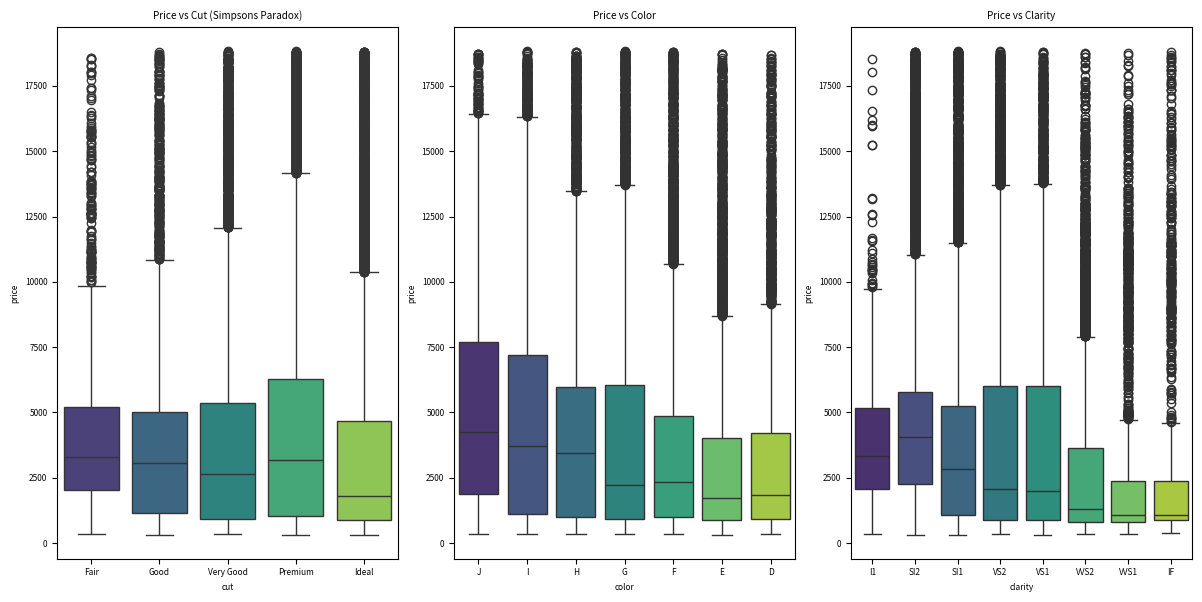

로그 변환된 예측값: 8.5
원래 가격으로 복원한 값: $4913.77
cut:Fair등급의 1사분면이 가장 높음.이를 통해 무게가 높은 다이몬드들이 존재한다는 것을 알 수있음. 
    하지만, Premium은 1사분면이 Fair등급에 비해 낮은 값에서 시작하는 반면에 3사분면이 가장 높음.
    무게가 가벼운 다이아몬드와 무게가 무거운 다이아몬드가 서로 섞여있다는 것을 알 수 있다.
color:품질이 낮을수록 사분위수의 범위가 높은 것으로 나타남.
      원래는 품질이 좋을 수록 가격도 높아야 함.
      이런 현상을 심슨의 역설 이라고 할 수 있음.
clarity:SI1과 VS2를 봤을 때, 분명 중위수는 SI1이 더 높은데 VS2의 이상치가 더 높은 곳에서 시작할까 라는 의문을 가짐.
    알고보니 S1


In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. 데이터 로드
try:
    df = sns.load_dataset('diamonds')
except:
    # 인터넷이 안 될 경우를 대비해 로컬 CSV 파일이 있다면 경로를 지정하세요.
    # df = pd.read_csv('diamonds.csv') 
    pass

# 2. 그래프 그리기 설정 (3개의 그래프를 나란히 배치)
fig, axes = plt.subplots(1, 3, figsize=(12, 6))

# 각 등급의 순서 정의 (나쁨 -> 좋음 순서)
# (분석할 때 순서가 뒤죽박죽되지 않게 지정해주는 것이 좋습니다)
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D'] # J가 가장 노랗고(나쁨), D가 투명함(좋음)
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF'] # I1이 내포물 많음(나쁨)

# --- (1) Cut 등급별 가격 분포 ---
sns.boxplot(x='cut', y='price', data=df, order=cut_order, ax=axes[0], palette='viridis')
axes[0].set_title('Price vs Cut (Simpsons Paradox)')

# --- (2) Color 등급별 가격 분포 ---
sns.boxplot(x='color', y='price', data=df, order=color_order, ax=axes[1], palette='viridis')
axes[1].set_title('Price vs Color')

# --- (3) Clarity 등급별 가격 분포 ---
sns.boxplot(x='clarity', y='price', data=df, order=clarity_order, ax=axes[2], palette='viridis')
axes[2].set_title('Price vs Clarity')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# [보너스] 로그 변환된 값을 원래 가격으로 되돌리는 코드 예시
# ---------------------------------------------------------

# 예: 모델이 예측한 로그 가격이 8.5라고 가정
predicted_log_price = 8.5

# 복원: np.log1p로 변환했다면 np.expm1로 되돌립니다. (그냥 log면 exp 사용)
original_price = np.expm1(predicted_log_price)

print(f"로그 변환된 예측값: {predicted_log_price}")
print(f"원래 가격으로 복원한 값: ${original_price:.2f}")
print(f"cut:Fair등급의 1사분면이 가장 높음.이를 통해 무게가 높은 다이몬드들이 존재한다는 것을 알 수있음. \n    하지만, Premium은 1사분면이 Fair등급에 비해 낮은 값에서 시작하는 반면에 3사분면이 가장 높음.\n    무게가 가벼운 다이아몬드와 무게가 무거운 다이아몬드가 서로 섞여있다는 것을 알 수 있다.")
print(f"color:품질이 낮을수록 사분위수의 범위가 높은 것으로 나타남.\n      원래는 품질이 좋을 수록 가격도 높아야 함.\n      이런 현상을 심슨의 역설 이라고 할 수 있음.")
print(f"clarity:SI1과 VS2를 봤을 때, 분명 중위수는 SI1이 더 높은데 VS2의 이상치가 더 높은 곳에서 시작할까 라는 의문을 가짐.\n    알고보니 S1")

📝 미션 5. “Premium 컷은 정말 더 비쌀까?”
Premium 컷 다이아몬드는 Ideal 컷보다 평균 가격이 높을까?<br>
이를 위해 - 가설을 직접 세우고 - 어떤 검정 방법이 적절한지 고민한 뒤 - 실제로 검정을 수행해 보자.<br>
검정 결과를 해석할 때는 “유의하다 / 유의하지 않다”에서 멈추지 말고, 이 차이가 얼마나 의미 있는 차이인<br>
지까지 함께 생각해 보자.

clarity가 가장 높은 F일 때 cut을 Premium으로 적용, Ideal로 이렇게 두 가지 조건을 적용했을 때<br>두 개의 조건에서 Premium컷의 평균 가격이 높다고 적용<br>
가격 차이가 cut때문인지, carat 분포 때문인지

H0 (귀무가설):<br>
clarity=F 조건에서 Premium과 Ideal의 평균 price는 같다.<br>

H1 (대립가설):<br>
clarity=F 조건에서 Premium의 평균 price는 Ideal보다 크다.<br>

👀단측검정("Premium이 더 비싼가?")👀

clarity = F (통제)<br>

cut = Premium vs Ideal (비교 대상)

In [28]:
df_F = origin[
    (origin['clarity'] == 'IF') &
    (origin['cut'].isin(['Premium', 'Ideal']))
].copy()


1차 탐색: 표본 수와 평균 확인 (검정 전 필수)

In [29]:
print(f"표본수가 극단적으로 불균형\npremium의 평균이 훨씬 큼\n하지만 중앙값 차이는 매우 작음\npremium 의 분산(std)이 훨씬 큼\n즉 표본수 불균형+분산차이=평균 비교 위험\n통계적으로 최악의 조합")
df_F.groupby('cut')['price'].agg(['count', 'mean', 'median', 'std'])


표본수가 극단적으로 불균형
premium의 평균이 훨씬 큼
하지만 중앙값 차이는 매우 작음
premium 의 분산(std)이 훨씬 큼
즉 표본수 불균형+분산차이=평균 비교 위험
통계적으로 최악의 조합


,count,mean,median,std
cut,,,,
Ideal,1212,2272.913366,1022.5,3320.846698
Premium,230,3856.143478,1148.0,4580.504841


사분위수 구조 분석

In [30]:
print(f"상위 10~20%에서 Premium 값만 급등")
df_F.groupby('cut')['price'].quantile([0.1, 0.25, 0.5, 0.75, 0.9]).unstack()


상위 10~20%에서 Premium 값만 급등


,0.10,0.25,0.50,0.75,0.90
cut,,,,,
Ideal,772.5,890.75,1022.5,1782.00,4205.6
Premium,873.4,984.00,1148.0,6283.25,11110.3


carat이라는 통제변수를 놓고 보아야 함<br>
심슨의 역설 해소

In [31]:
df_slice = df_F[df_F['carat'].between(0.9, 1.1)]

df_slice.groupby('cut')['price'].agg(['count','mean','median','std'])


,count,mean,median,std
cut,,,,
Ideal,48,10934.604167,10989.5,2999.113718
Premium,28,10253.071429,9025.5,3313.765755


cut으로 t-test 수행

In [32]:
from scipy.stats import ttest_ind
premium_price = df_slice[df_slice['cut'] == 'Premium']['price']
ideal_price   = df_slice[df_slice['cut'] == 'Ideal']['price']

t_test = ttest_ind(premium_price, ideal_price, equal_var=False)
print(t_test)
print(f"cut을 주요인으로 두었을 때 유의하지 않다")

TtestResult(statistic=np.float64(-0.8952287384561094), pvalue=np.float64(0.3747800050435417), df=np.float64(52.12924219583759))
cut을 주요인으로 두었을 때 유의하지 않다


회귀로 carat 통제

In [33]:
import statsmodels.formula.api as smf

model = smf.ols(
    'price ~ C(cut) + carat',
    data=df_F
).fit()

model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.877
Model:                            OLS   Adj. R-squared:                  0.877
Method:                 Least Squares   F-statistic:                     5152.
Date:                Mon, 15 Dec 2025   Prob (F-statistic):               0.00
Time:                        17:19:58   Log-Likelihood:                -12339.
No. Observations:                1442   AIC:                         2.468e+04
Df Residuals:                    1439   BIC:                         2.470e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -2870.5799     62.895    -45.641      0.000   -2993.956   -2747.203
C(cut)[T.Premium]   -94.6062     92.165     -1.026      0.305    -275.399      86.187
carat               1.13e+04    113.040     99.994      0.000    1.11e+04    1.15e+04
==============================================================================
Omnibus:                      755.955   Durbin-Watson:                   1.128
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            12078.507
Skew:                           2.061   Prob(JB):                         0.00
Kurtosis:                      16.566   Cond. No.                         4.31
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

clarity가 최상위급인 F인 상태를 고정하고 Ideal과 Premium을 비교했을 때, carat 때문에 Premium에서 평균가격이 높다고 나와버림.<br>
하지만, carat을 통제변수로 두었을 때 Ideal과 Premium간의 가격 차이가 유의미해짐.<br>
즉 가격에 가장 큰 영향을 미치는 요인은 cut이 아닌 carat으로 결론을 내릴 수 있음

📝 미션 6. “모든 컷은 서로 다를까?”<br>
이번에는 컷 등급 전체를 놓고 생각해 보자.<br>
cut에 따른 가격 차이가 전반적으로 존재하는지 분산분석으로 확인해 보고, 차이가 있다면 어떤 컷들 사이<br>
에서 차이가 발생하는지 사후검정을 통해 살펴보자.<br>
이 결과를 “가격 서열표”처럼 정리해 보는 것도 좋다.

In [34]:
# 표본 수 확인
print(f"Fair등급이 극단적으로 작다")
origin['cut'].value_counts()


Fair등급이 극단적으로 작다


cut
Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610
Name: count, dtype: int64

분산의 동질성

In [35]:
from scipy.stats import levene

groups = [
    origin[origin['cut'] == c]['price']
    for c in origin['cut'].unique()
]

levene_result = levene(*groups)
alpha = 0.05

print(levene_result)
print(
    f"Levene test p-value = {levene_result.pvalue:.3e} → "
    f"{'분산이 동일하지 않음' if levene_result.pvalue < alpha else '분산이 동일함'}\n"
    f"cut등급 간 가격 분산은 동일하지 않다고 나옴.\n이후 분석에서는 분산 불균등성을 고려한 해석이 필요")




LeveneResult(statistic=np.float64(123.59529396129993), pvalue=np.float64(3.360146858232803e-105))
Levene test p-value = 3.360e-105 → 분산이 동일하지 않음
cut등급 간 가격 분산은 동일하지 않다고 나옴.
이후 분석에서는 분산 불균등성을 고려한 해석이 필요


일원분산분석 실행

In [36]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols('price ~ C(cut)', data=origin).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

anova_table


,sum_sq,df,F,PR(>F)
C(cut),1.104175e+10,4.0,175.688717,8.428307e-150
Residual,8.474314e+11,53935.0,NaN,NaN


사후검정: Tukey HSD

In [37]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=origin['price'],
    groups=origin['cut'],
    alpha=0.05
)

print(tukey)
print(f"상위컷과 하위컷간의 차이가 어마무시하게 났다.")


     Multiple Comparison of Means - Tukey HSD, FWER=0.05      
 group1   group2   meandiff p-adj    lower      upper   reject
--------------------------------------------------------------
   Fair      Good -429.8933 0.0015  -740.4593 -119.3273   True
   Fair     Ideal -901.2158    0.0 -1180.5808 -621.8507   True
   Fair   Premium  225.4999 0.1951   -59.2763  510.2762  False
   Fair Very Good -376.9979 0.0031  -663.8719  -90.1239   True
   Good     Ideal -471.3225    0.0  -642.3685 -300.2765   True
   Good   Premium  655.3933    0.0   475.6451  835.1414   True
   Good Very Good   52.8954 0.9341  -130.1581  235.9489  False
  Ideal   Premium 1126.7157    0.0  1008.8048 1244.6267   True
  Ideal Very Good  524.2179    0.0    401.327  647.1088   True
Premium Very Good -602.4978    0.0  -737.2377 -467.7579   True
--------------------------------------------------------------
상위컷과 하위컷간의 차이가 어마무시하게 났다.


가격 서열표

In [38]:
# cut별 평균 가격
mean_price = origin.groupby('cut')['price'].mean().sort_values()
mean_price


cut
Ideal        3457.541970
Good         3928.864452
Very Good    3981.759891
Fair         4358.757764
Premium      4584.257704
Name: price, dtype: float64

📝미션7."품질 요인들은 서로 영향을 주고받을까?"

In [52]:
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

# stats모델 이용
df['log_price'] = np.log(df['price'])
df['log_carat'] = np.log(df['carat'])

model_main = smf.ols(
    'log_price ~ log_carat + C(cut) + C(color) + C(clarity)',
    data=df
).fit()

model_inter = smf.ols(
    'log_price ~ log_carat \
     + C(cut) * C(color) \
     + C(cut) * C(clarity) \
     + C(color) * C(clarity)',
    data=df
).fit()


print(f"제곱합 차이로 인해 가격 변동을 매우 크게 설명함")
print(f"F통계량을 통해 수치가 극단적으로 나왔다는 것을 알 수 있음")
print(f"Cut과 clarity의 상호작용 항을 포함한 모델은 주효과 모델에 비해 통계적으로 유의미한 설명력 증가를 보였으며(F = 57.85, p < 0.001),\n"
      f"이는 컷 품질의 가격 효과가 투명도 수준에 따라 달라지는\n"
      f"체계적인 상호작용 구조가 존재함을 의미한다.")
anova_lm(model_main, model_inter)


제곱합 차이로 인해 가격 변동을 매우 크게 설명함
F통계량을 통해 수치가 극단적으로 나왔다는 것을 알 수 있음
Cut과 clarity의 상호작용 항을 포함한 모델은 주효과 모델에 비해 통계적으로 유의미한 설명력 증가를 보였으며(F = 57.85, p < 0.001),
이는 컷 품질의 가격 효과가 투명도 수준에 따라 달라지는
체계적인 상호작용 구조가 존재함을 의미한다.


,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,53921.0,965.341763,0.0,NaN,NaN,NaN
1,53827.0,876.771173,94.0,88.570589,57.846301,0.0


📘

clarity가 SI2이고 color을 최고등급인 D로 적용했을 때의 Price

In [40]:
df_filtered = origin[
    (origin['clarity'] == 'SI2') &
    (origin['color'] == 'D')
]

df_filtered['price']

df_filtered.describe()


,price,carat,x,y,z,depth,table
count,1370.00000,1370.000000,1370.000000,1370.000000,1370.000000,1370.000000,1370.000000
mean,3931.10146,0.872168,5.961168,5.957321,3.673993,61.700511,58.035912
std,3532.47702,0.430046,1.014900,1.010695,0.614844,1.712765,2.413196
min,413.00000,0.230000,3.870000,3.850000,2.450000,54.300000,52.000000
25%,1243.00000,0.510000,5.122500,5.120000,3.170000,60.700000,56.000000
50%,3468.00000,0.900000,6.130000,6.135000,3.790000,61.800000,58.000000
75%,4937.25000,1.050000,6.590000,6.580000,4.040000,62.700000,60.000000
max,18693.00000,2.580000,9.080000,9.010000,5.330000,71.600000,69.000000


clarity가 SI2이고 color을 최저등급인 J로 적용했을 때의 price

In [41]:
df_SI2_J = origin[
    (origin['clarity'] == 'SI2') &
    (origin['color'] == 'J')
]

df_SI2_J['price']
df_SI2_J.describe()


,price,carat,x,y,z,depth,table
count,479.000000,479.000000,479.000000,479.000000,479.000000,479.000000,479.000000
mean,6520.958246,1.424259,7.070104,7.056054,4.367286,61.872234,58.142797
std,4429.180787,0.568902,0.992992,0.993131,0.606230,1.689755,2.414813
min,335.000000,0.300000,4.340000,4.240000,2.610000,56.200000,53.000000
25%,3482.000000,1.020000,6.430000,6.420000,4.010000,60.900000,56.600000
50%,4656.000000,1.240000,6.880000,6.890000,4.270000,62.000000,58.000000
75%,10664.000000,2.010000,8.025000,8.035000,4.960000,62.700000,60.000000
max,18710.000000,3.010000,9.410000,9.320000,5.690000,69.900000,68.000000


SI2->color가 D일 때와 J 일 때

In [42]:
SI2_DJ = origin[
    (origin['clarity'] == 'SI2') &
    (origin['color'].isin(['D', 'J']))
].groupby('color')['price'].describe()

print(SI2_DJ)

print(f"====왜 큰 다이아몬드는 최저등급인 J에 몰릴 수 밖에 없는가?====")
print(f"1.큰 원석일수록 결함,색이 생길 확률이⬆️\n완전히 무색 + 결함 적음 + 큼 ----> 자연적으로 거의 불가능\n2.시장에서의 타협\n-크기를 택하면->색/선명도를 포기\n-색을 택하면->크기를 포기")

print(f"\n         ✏️결론✏️")
print(f"알이 큰 다이아몬드는 원래 적고,특히 색과 선명도가 좋은 조합에서는 극도로 희귀하다.\n그래서 큰 다이아몬드들은 상대적으로 낮은 color(J 등급)에 몰리며,그 결과 해당 그룹의 평균 가격이 높아 보이게 된다.")

        count         mean          std    min     25%     50%       75%  \
color                                                                      
D      1370.0  3931.101460  3532.477020  413.0  1243.0  3468.0   4937.25   
J       479.0  6520.958246  4429.180787  335.0  3482.0  4656.0  10664.00   

           max  
color           
D      18693.0  
J      18710.0  
====왜 큰 다이아몬드는 최저등급인 J에 몰릴 수 밖에 없는가?====
1.큰 원석일수록 결함,색이 생길 확률이⬆️
완전히 무색 + 결함 적음 + 큼 ----> 자연적으로 거의 불가능
2.시장에서의 타협
-크기를 택하면->색/선명도를 포기
-색을 택하면->크기를 포기

         ✏️결론✏️
알이 큰 다이아몬드는 원래 적고,특히 색과 선명도가 좋은 조합에서는 극도로 희귀하다.
그래서 큰 다이아몬드들은 상대적으로 낮은 color(J 등급)에 몰리며,그 결과 해당 그룹의 평균 가격이 높아 보이게 된다.


In [43]:
# color 분포
print(f"D 표본수가 매우 작아, D가 희긔하지만 비싸다는 것을 알 수 있음")
df_big_SI2['color'].value_counts()



D 표본수가 매우 작아, D가 희긔하지만 비싸다는 것을 알 수 있음


NameError: name 'df_big_SI2' is not defined

In [ ]:
# carat 분포
print(f"여전히 심슨의 역설이 적용")
df_big_SI2.groupby('color')['carat'].describe()


여전히 심슨의 역설이 적용


,count,mean,std,min,25%,50%,75%,max
color,,,,,,,,
D,161.0,1.730435,0.253119,1.5,1.520,1.600,2.00,2.58
E,232.0,1.747112,0.261658,1.5,1.510,1.610,2.01,2.71
F,224.0,1.830446,0.276752,1.5,1.540,1.935,2.03,2.67
G,311.0,1.896945,0.295814,1.5,1.545,2.010,2.07,3.01
H,455.0,1.930330,0.323658,1.5,1.560,2.010,2.13,3.01
I,387.0,1.969793,0.343648,1.5,1.600,2.020,2.18,3.04
J,194.0,2.017423,0.345987,1.5,1.710,2.020,2.21,3.01


carat >= 1.5 로 고정했을 때<br>
큰 알, SI2로 고정

In [ ]:
print(f"carat >= 1.5로 고정하고 나니 D가 J보다 비싸지는 '정상적인 구조'가 생성.\n         심슨의 역설 해걸")
df_big = origin[origin['carat'] >= 1.5]
df_big_SI2 = df_big[df_big['clarity'] == 'SI2']
df_big_SI2[
    df_big_SI2['color'].isin(['D', 'J'])
].groupby('color')['price'].describe()


carat >= 1.5로 고정하고 나니 D가 J보다 비싸지는 '정상적인 구조'가 생성.
         심슨의 역설 해걸


,count,mean,std,min,25%,50%,75%,max
color,,,,,,,,
D,161.0,11710.919255,3353.820357,6596.0,9030.00,10546.0,13485.00,18693.0
J,194.0,11049.159794,3393.024211,5107.0,7743.25,11817.5,13144.25,18710.0
